# Decoding Faces and Orientations from Macaque AM Neural Activity 
### December 5, 2025

**Authors:** [Arkesh Das](https://www.linkedin.com/in/arkesh-das) and [Lowell Monis](https://www.linkedin.com/in/lowell-monis)

This is a capstone of the methods, techniques, ideas, and processes that constitute the content covered in the second section of Computational Mathematics, Science, and Engineering 381, titled Fundamentals of Data Science Methods at Michigan State University during the fall semester of 2025. The project was conducted under the instruction of [Mengsen Zhang](https://directory.natsci.msu.edu/directory/Profiles/Person/104281), Ph. D., Assistant Professor of Computational Mathematics, Science, and Engineering, and Neuroscience, in partial fulfillment of the requirements of the course.

## Background and Motivation

Face recognition is one of the most remarkable computational feats performed by the primate brain. It is difficult to comprehend how this neurological function takes place, for something that is very natural--an unimpressive process that happens every waking moment, but in reality is the sheer beauty of how primate brains work. Despite dramatic changes in viewing conditions--different lighting, distances, angles, and head orientations--we effortlessly recognize familiar individuals. This ability is so fundamental to primate social behavior that evolution has dedicated specialized neural machinery to solve it. Understanding how the brain achieves invariant face recognition remains a central question in neuroscience and has direct implications for artificial intelligence, as modern computer vision systems still struggle with the robustness that biological systems achieve naturally. Moreover, these application systems are very prone to bias, which makes improving the understanding of this intuitive primal process important while pursuing advancements in facial recognition technology.

### The Macaque Face-Processing System

Neuroscience research has revealed that the macaque monkey brain contains a hierarchical network of six discrete face-selective regions, called "face patches," located in the temporal lobe. These regions were discovered through functional magnetic resonance imaging (fMRI) and confirmed through single-neuron recordings to contain neurons that respond much more strongly to faces than to other visual objects [1], [2].

The face patch system is organized as a processing hierarchy with three main levels:

- Posterior patches (PL): Initial face detection
- Middle patches (ML/MF): View-specific feature extraction
- Anterior patches (AL/AM): View-invariant identity representation

The anterior medial (AM) face patch, which is the focus of our study, and the data we are using, courtesy to Friewald and Tsao [2], represents the apex of this hierarchy. Freiwald and Tsao [2] demonstrated that neurons in AM exhibit remarkable properties: they respond selectively to specific individuals across dramatically different head orientations: from full left profile to full right profile, from looking up to looking down. This "view-invariant" coding allows the monkey to recognize the same individual regardless of head pose, solving one of the fundamental challenges of object recognition.

### The Dataset: Neural Recordings from Face-Selective Neurons

Our dataset consists of electrophysiological recordings from 193 individual neurons in the AM face patch of two macaque monkeys, Bert and Lupo. The experimental paradigm was simple yet powerful: monkeys passively viewed images of 25 different human individuals presented at 8 different head orientations:

- left full profile
- left three-quarter profile
- frontal
- right three-quarter profile
- right full profile
- upward
- downward
- back of head.

Each image was displayed for 200ms followed by a 200ms blank interval, while researchers recorded the precise timing of neural activity, which the authors call action potentials or "spikes".

The data is organized in a "raster format"--a standard representation in neuroscience where each row corresponds to one trial (one presentation of a specific face image), and each column represents a 1-millisecond time bin spanning 800ms from stimulus onset. A value of 1 indicates the neuron fired an action potential during that millisecond; a value of 0 indicates the neuron was silent. This temporal precision allows us to track how neural representations evolve over time as visual information flows through the brain's processing hierarchy.

This dataset was originally collected by Freiwald and Tsao and subsequently analyzed by Meyers et al. [3] using neural decoding techniques. Their work demonstrated that the AM population contains rich information about facial identity that generalizes across head poses, and that this pose-invariant information increases systematically from posterior to anterior face patches. Our project builds on this foundation by applying multiple machine learning methods to extract different aspects of information from these neural population responses.

### Objectives

The neural activity patterns in the AM face patch encode multiple types of information simultaneously--which individual is being viewed, what orientation their head is in, etc. By applying different analytical methods, we can probe what information is present in these neural responses and how it is organized. Our project addresses the following questions:

1. **Can neural representations in the anterior medial region generalize face identity across different head orientations, achieving view-invariant recognition?** Specifically, when a classifier is trained to recognize individuals from one head orientation (e.g., frontal views), can it successfully identify those same individuals when presented with different orientations (e.g., profile or tilted views)? To address this question, we will employ Support Vector Classifiers to decode face identity from neural population activity in the peak post-stimulus window. We will train separate SVM models on data from individual head orientations and systematically test their ability to generalize to all other orientations, creating an 8×8 generalization matrix that reveals which viewing angles share similar neural representations.

2. **Which stimulus dimensions--person identity versus head orientation--drive neural population responses most strongly?** While classification tells us what information can be extracted, regression approaches reveal what variables neural populations are actually encoding. By predicting the magnitude of neural responses from stimulus properties, we can quantify the relative importance of identity versus pose information and test whether AM prioritizes identity coding as the previous literature suggests.

## Methodology

One can commence this analysis by importing standard libraries and packages that will be used in this project. We will also set a plotting style and palette.

In [21]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Next, we will focus on importing and exploring our data. The data is provided to us in the form of rasters, with the rows denoting a trial and the columns denoting the time bins and other information identifying each trial. We will be concatenating these rasters. First, let's identify the number of comma-separated value files provided to us.

In [3]:
search_path = "data/*.csv" 
all_files = glob.glob(search_path, recursive=True)
processed_dfs = []
raster_files = [f for f in all_files if "raster_data" in f.lower()]

print(f"Found {len(raster_files)} files.")

Found 193 files.


We have found 193 rasters. Each raster represents a unique neural recording site on one of the two macaques. Below, one can find the concatenator function imported from the script `data_generator.py`. The cell below can be activated and run if one needs to generate a concatenated data file. This will take a signficant amount of time to complete. Post-generation, one can use the cell that follows to import the data as a CSV instead, since the generator saves a copy of the data in the `data` directory as `data.csv` by default. Set `save=False` if you would not like to save a copy of the data.

In [4]:
data = pd.read_csv("data/data.csv")

In [5]:
data.shape

(206216, 807)

One can conclude that there have been 206,216 trials across all of these 193 sites. It also looks like there are no missing values in the data.

In [6]:
null_count=data.isnull().sum()
null_count[null_count>0]

Next, we can conduct sanity checks to verify if our data has been imported correctly by verifying facts with the literature. There are two monkeys, Bert and Lupo, and we only have the data for recording done on the anterior medial region, which is the scope of this analysis. There are 25 unique people whose facial orientations have been shown to the monkeys, with eight such orientations each. The data has time bins for 800ms, out of which only the first 400ms are relevant to our analysis, since most stimulus after the 400ms mark is not of much use as per the authors of the literature [2].

In [8]:
print(f"Monkeys: {data['site_info.monkey'].nunique()}")
print(f"Regions: {data['site_info.region'].unique()}")
print(f"People: {data['labels.person'].nunique()}")
print(f"Orientations: {data['labels.orientation'].nunique()}")
print(f"Time bins: {len([col for col in data.columns if col.startswith('time.')])}")

Monkeys: 2
Regions: ['am']
People: 25
Orientations: 8
Time bins: 800


From the sanity check, we can conclude that our data fits the literature. Next, we can proceed with label encoding the people whose faces were introduced in the study, and their facial orientations.

In [9]:
le_person = LabelEncoder()
data['person_encoded'] = le_person.fit_transform(data['labels.person'])

le_orient = LabelEncoder()
data['orient_encoded'] = le_orient.fit_transform(data['labels.orientation'])
orientation_labels = le_orient.classes_

Considering we will be addressing classification problems, it is important to ensure that our classes are as balanced as possible to avoid introducing skewed models due to class imbalance. If classes are imbalanced, our methods need to use stratifications. To that end, let us visualize the breakdown of different classes in the data.

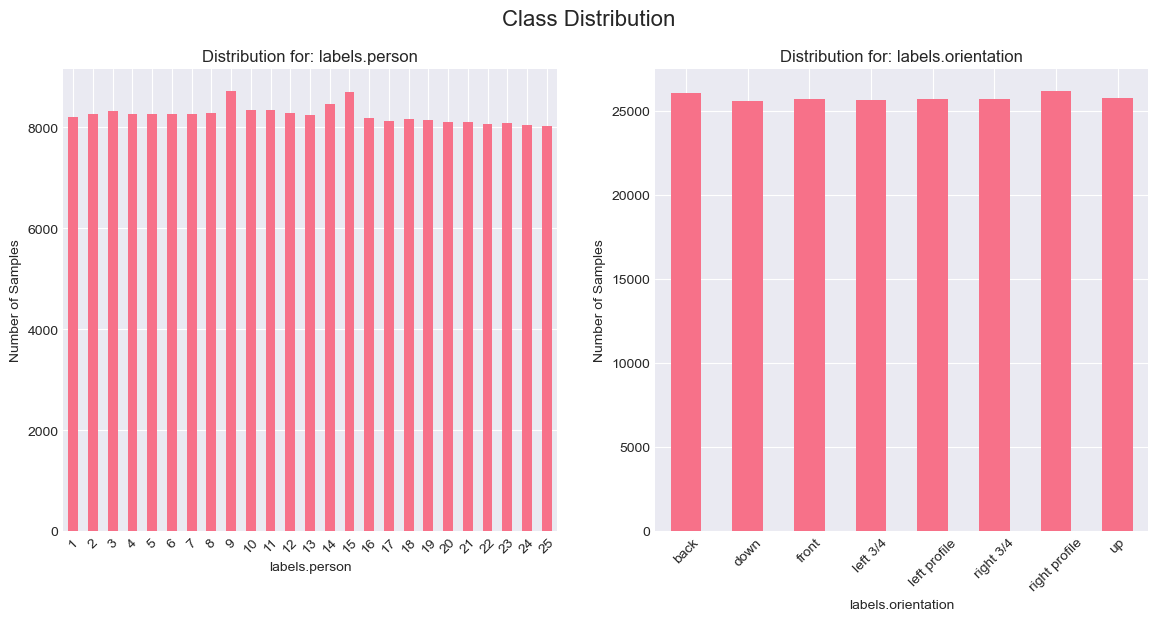

In [10]:
class_columns = ['labels.person', 'labels.orientation']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plt.suptitle('Class Distribution', fontsize=16)

for i, col in enumerate(class_columns):
    class_counts = data[col].value_counts().sort_index()
    class_counts.plot(kind='bar', ax=axes[i], rot=45)
    axes[i].set_title(f'Distribution for: {col}', fontsize=12)
    axes[i].set_ylabel('Number of Samples')
    axes[i].set_xlabel(col)

All of our classes look almost identical in magnitude with very little variation. The classes are almost balanced, and hence there is no explicit need for stratification. Next, we will be splitting our columns into various windows. We will then compute the column-wise means of the trials within these ranges.

For work involving support vector machines and other intensive training, we decided to use aggregated data to cut down on training time. We will be aggregating the spike means over all trials by site, the macaque, person and their facial orientation visualized. We are include details about the macaque since there can be both Lupo and Bert can have sites with the same number. A verification of this can be shown when calculating the number of unique site numbers. The number is less than 193, which is indicative of our concern.

In [17]:
data['site'].nunique()

155

In [16]:
site_counts = data['site'].value_counts()
grouping_cols = ['site', 'site_info.monkey', 'person_encoded', 'orient_encoded']
time_cols = [col for col in subset_data.columns if col.startswith('time.')] 
aggregated_data = data.groupby(grouping_cols)[time_cols].mean().reset_index()
aggregated_data.shape

(38581, 804)

It looks like there are 38,581 unique combinations of sites. Next, we will subset into the peak window as dictated by the literature. All time bins post 400ms are redundant, considering they hardly have any firing values available. We will instead focus on 150-250ms which is the peak window, where most of the decoding happens post-stimulus [3]. This also eliminates noise in the data. 

Visual information requires approximately 100ms to propagate from the retina through the visual hierarchy to reach the anterior medial (AM) face patch [2]. Prior studies have shown that face-selective responses in AM emerge around 100-150ms post-stimulus onset, with peak identity information occurring between 150-300ms [3]. Including the 0-100ms period would incorporate neural activity that reflects pre-stimulus baseline firing and non-specific visual onset responses rather than face-specific identity information.

In [18]:
peak_window = [f'time.{i}_{i+1}' for i in range(150, 250)]

The aggregated firing values in the peak window are the features we are considering for the support vector classifier to address the first question. The response will be determining the person being identified/decoded.

In [19]:
X = aggregated_data[peak_window].values
y = aggregated_data['person_encoded'].values
orientation = aggregated_data['orient_encoded'].values

Next, we will scale the data in preparation for support vector classification.

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean after scaling: {X_scaled.mean():.4f}")
print(f"Standard deviation after scaling: {X_scaled.std():.4f}")

Mean after scaling: 0.0000
Standard deviation after scaling: 1.0000


The data has been standardized perfectly and is now in the form $X\sim\mathcal{N}(0,1)$. We will now proceed with a train-test split.

In [23]:
X_train, X_test, y_train, y_test, orient_train, orient_test = train_test_split(
    X_scaled, y, orientation,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [16]:
print(f"  - Shape: {X.shape}")
print(f"  - Features: Neural activity in {len(peak_window)} time bins")
print(f"  - Mean firing rate: {X.mean():.4f}")
print(f"  - Sparsity (% zeros): {(X == 0).mean() * 100:.2f}%")

  - Shape: (206216, 100)
  - Features: Neural activity in 100 time bins
  - Mean firing rate: 0.0057
  - Sparsity (% zeros): 99.43%


In [17]:
print(f"  - Training samples: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  - Test samples: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  - Chance accuracy (random guessing): {1/25*100:.2f}%")

  - Training samples: 164,972 (80.0%)
  - Test samples: 41,244 (20.0%)
  - Chance accuracy (random guessing): 4.00%


In [18]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score = True
)

In [19]:
rf_baseline.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [20]:
y_pred_baseline = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

In [21]:
print(f"\nBaseline Performance:")
print(f"  - Test Accuracy: {baseline_accuracy*100:.2f}%")
print(f"  - Improvement over chance: {(baseline_accuracy - 1/25)*100:.2f} percentage points")


Baseline Performance:
  - Test Accuracy: 4.31%
  - Improvement over chance: 0.31 percentage points


In [32]:
param_grid = {
    'n_estimators': [20, 200, 300],
    'max_depth': [10, 20, 30],
    'max_features': ['sqrt', 0.5, 0.25]
}

In [33]:
print(f"\nParameter Grid:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")


Parameter Grid:
  - n_estimators: [100, 200, 300]
  - max_depth: [10, 20, 30]
  - max_features: ['sqrt', 0.5, 0.25]


In [34]:
total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations to test: {total_combinations}")


Total combinations to test: 27


In [35]:
rf = RandomForestClassifier(random_state=381, oob_score = True)

In [36]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=2
)

SVM ANALYSIS: POSE-INVARIANT FACE IDENTITY DECODING

Data loaded: 206,216 trials across 807 columns

Dataset Overview:
  - Number of recording sites: 155
  - Number of monkeys: 2
  - Number of individuals (people): 25
  - Number of orientations: 8

Orientations in dataset:
  0. back                : 26,024 trials
  1. down                : 25,580 trials
  2. front               : 25,691 trials
  3. left 3/4            : 25,648 trials
  4. left profile        : 25,698 trials
  5. right 3/4           : 25,658 trials
  6. right profile       : 26,160 trials
  7. up                  : 25,757 trials

Using peak response window: 150-250ms (100 time bins)

Feature Matrix:
  - Shape: (206216, 100)
  - Mean firing rate: 0.0057
  - Sparsity (% zeros): 99.43%

After standardization:
  - Mean: -0.0000
  - Std: 1.0000

STEP 1: BASELINE LINEAR SVM

Train-Test Split:
  - Training samples: 164,972
  - Test samples: 41,244
  - Chance accuracy: 4.00%

Training baseline SVM...

Baseline Performance:
  - 

In [ ]:
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

## References

[1] D. Y. Tsao, W. A. Freiwald, R. B. Tootell, and M. S. Livingstone, "A cortical region consisting entirely of face-selective cells," *Science*, vol. 311, no. 5670, pp. 670-674, Feb. 2006.

[2] W. A. Freiwald and D. Y. Tsao, "Functional compartmentalization and viewpoint generalization within the macaque face-processing system," *Science*, vol. 330, no. 6005, pp. 845-851, Nov. 2010.

[3] E. M. Meyers, M. Borzello, W. A. Freiwald, and D. Tsao, "Intelligent information loss: The coding of facial identity, head pose, and non-face information in the macaque face patch system," *J. Neurosci.*, vol. 35, no. 18, pp. 7069-7081, May 2015.